# 05 — Explainability, Stability, and Fairness
## What Regulators Ask After the AUROC Slide

**Credit Scoring Capstone — Module 1**

A credit model is only deployable if three non-statistical questions have answers:

1. **"Why was this applicant declined?"** — Under FCAC consumer-protection guidelines (and ECOA/Reg B in the US), every adverse decision needs specific principal reasons. SHAP values give a per-applicant decomposition; we turn the top-4 negative contributors into plain-language reason codes.
2. **"How will you know when the model breaks?"** — Population Stability Index (PSI) on the score and on key features, with thresholds that trigger review. We demonstrate the tool on a simulated stressed cohort so the monitoring is *proven*, not just promised.
3. **"Does it disadvantage protected groups?"** — The model as trained ingests `CODE_GENDER`. That is a compliance defect regardless of accuracy. We measure the disparate impact, retrain without the protected attribute, and quantify what the fix costs.

In [1]:
import sys, warnings, json
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import roc_auc_score

from src import config, plotting
from src.evaluation import credit_metrics, psi
from src.plotting import (BLUE, ORANGE, AQUA, YELLOW, MUTED, INK_2, GRID, GOOD,
                          CRITICAL, fmt_pct, subtitle, save_figure)

plotting.apply_style()
config.set_seed()

champion = joblib.load(config.MODELS_DIR / "credit_scoring_pipeline.pkl")
res04 = json.load(open(config.PROCESSED_DIR / "results_04.json"))
THRESHOLD = res04["threshold"]

train = pd.read_parquet(config.PROCESSED_DIR / "train_features.parquet")
val = pd.read_parquet(config.PROCESSED_DIR / "val_features.parquet")
test = pd.read_parquet(config.PROCESSED_DIR / "test_features.parquet")
meta = json.load(open(config.PROCESSED_DIR / "feature_meta.json"))
for d in (train, val, test):
    d["PEER_GROUP"] = "group_" + d["PEER_GROUP"].astype(str)
num_cols = [c for c in meta["numeric"] if c != "PEER_GROUP"]
cat_cols = meta["categorical"] + ["PEER_GROUP"]
FEATURES = num_cols + cat_cols
print(f"champion loaded \u00b7 decline threshold {THRESHOLD}")

champion loaded · decline threshold 0.07


---
## 1. SHAP: Opening the Boosted Model

`TreeExplainer` decomposes each prediction into per-feature contributions (in log-odds). We explain a 5,000-application sample of the sealed test set through the champion's own preprocessing, so explanations refer to exactly what the model saw.

In [2]:
prep = champion.named_steps["prep"]
clf = champion.named_steps["clf"]

rng = np.random.default_rng(config.SEED)
sample_idx = rng.choice(len(test), 5000, replace=False)
sample = test.iloc[sample_idx].reset_index(drop=True)
X_sample = prep.transform(sample[FEATURES])
feat_names = prep.get_feature_names_out()

explainer = shap.TreeExplainer(clf)
sv = explainer(X_sample)
sv.feature_names = list(feat_names)
print(f"SHAP values: {sv.values.shape}")

SHAP values: (5000, 282)


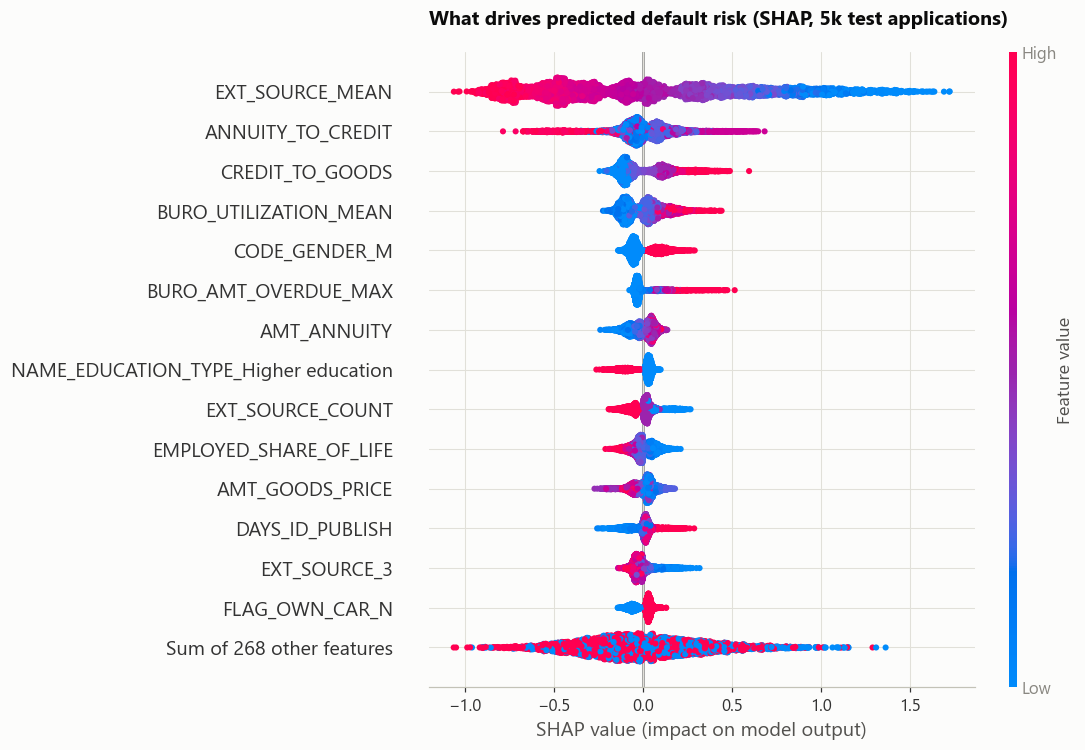

In [3]:
fig = plt.figure(figsize=(9, 7))
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("What drives predicted default risk (SHAP, 5k test applications)",
          fontsize=13, fontweight="bold", loc="left", pad=18)
plt.gcf().set_facecolor("#fcfcfb")
save_figure(plt.gcf(), "exp_shap_beeswarm")
plt.show()

**Reading the beeswarm:** each dot is one applicant; position = how much that feature pushed their risk up (right) or down (left); color = the feature's value (red high, blue low). The external scores dominate exactly as the single-feature analysis predicted — low `EXT_SOURCE` values push risk up hard. Age, employment tenure, and the credit-to-goods ratio behave monotonically and in the economically expected direction — a sanity check that the model learned lending, not noise.

---
## 2. Adverse Action: "State the Top 4 Reasons"

For any declined applicant, the four largest positive (risk-increasing) SHAP contributions become the principal reasons, translated to consumer-readable language.

In [4]:
REASON_MAP = {
    "EXT_SOURCE": "Low external credit bureau score",
    "AGE_YEARS": "Limited length of credit and personal history",
    "DAYS_BIRTH": "Limited length of credit and personal history",
    "EMPLOYED": "Short or unstable employment history",
    "DTI": "High debt payment relative to income",
    "ANNUITY": "High payment burden on requested credit",
    "CREDIT_TO_GOODS": "Requested credit high relative to purchase value",
    "CREDIT_TO_INCOME": "Requested credit high relative to income",
    "BURO_OVERDUE": "Past-due payments on existing credit obligations",
    "BURO_UTILIZATION": "High utilization of existing credit lines",
    "BURO_DEBT": "High outstanding debt at other lenders",
    "BURO_ACTIVE": "Number of active credit obligations at other lenders",
    "BURO_COUNT": "Number of existing credit obligations",
    "BURO_OLDEST": "Limited length of credit history",
    "BURO_NEWEST": "Recently opened credit obligations",
    "BURO_PROLONG": "Extensions taken on existing credit",
    "BURO_TYPES": "Mix of existing credit types",
    "HAS_BUREAU": "Limited credit bureau history",
    "AMT_INCOME": "Income level relative to requested credit",
    "OWN_CAR_AGE": "Limited asset profile",
    "REGION_RATING": "Regional risk factors",
    "DOCUMENT": "Incomplete application documentation",
    "PHONE": "Recent changes to contact information",
    "BUILDING": "Incomplete housing information",
    "OCCUPATION": "Occupation category risk factors",
    "ORGANIZATION": "Employer category risk factors",
}

def plain_reason(feature_name):
    for key, text in REASON_MAP.items():
        if key in feature_name.upper():
            return text
    return f"Risk factors related to {feature_name}"

def adverse_action_reasons(shap_row, k=4):
    order = np.argsort(-shap_row.values)
    reasons, seen = [], set()
    for i in order:
        if shap_row.values[i] <= 0:
            break
        r = plain_reason(str(sv.feature_names[i]))
        if r not in seen:
            reasons.append(r); seen.add(r)
        if len(reasons) == k:
            break
    return reasons

pd_sample = clf.predict_proba(X_sample)[:, 1]
declined_mask = pd_sample >= THRESHOLD
declined_ids = np.where(declined_mask)[0]
print(f"declined in sample at threshold {THRESHOLD}: {declined_mask.sum()} of {len(sample)}")

# one concrete applicant, end to end
i = int(declined_ids[0])
print(f"\n--- ADVERSE ACTION NOTICE (illustrative) ---")
print(f"Application: SK_ID_CURR {int(sample.loc[i, 'SK_ID_CURR'])}")
print(f"Predicted probability of payment difficulties: {pd_sample[i]:.1%}")
print("Principal reasons for the decision:")
for j, r in enumerate(adverse_action_reasons(sv[i]), 1):
    print(f"  {j}. {r}")

declined in sample at threshold 0.07: 1861 of 5000

--- ADVERSE ACTION NOTICE (illustrative) ---
Application: SK_ID_CURR 255668
Predicted probability of payment difficulties: 8.3%
Principal reasons for the decision:
  1. Number of active credit obligations at other lenders
  2. High utilization of existing credit lines
  3. Requested credit high relative to purchase value
  4. High payment burden on requested credit


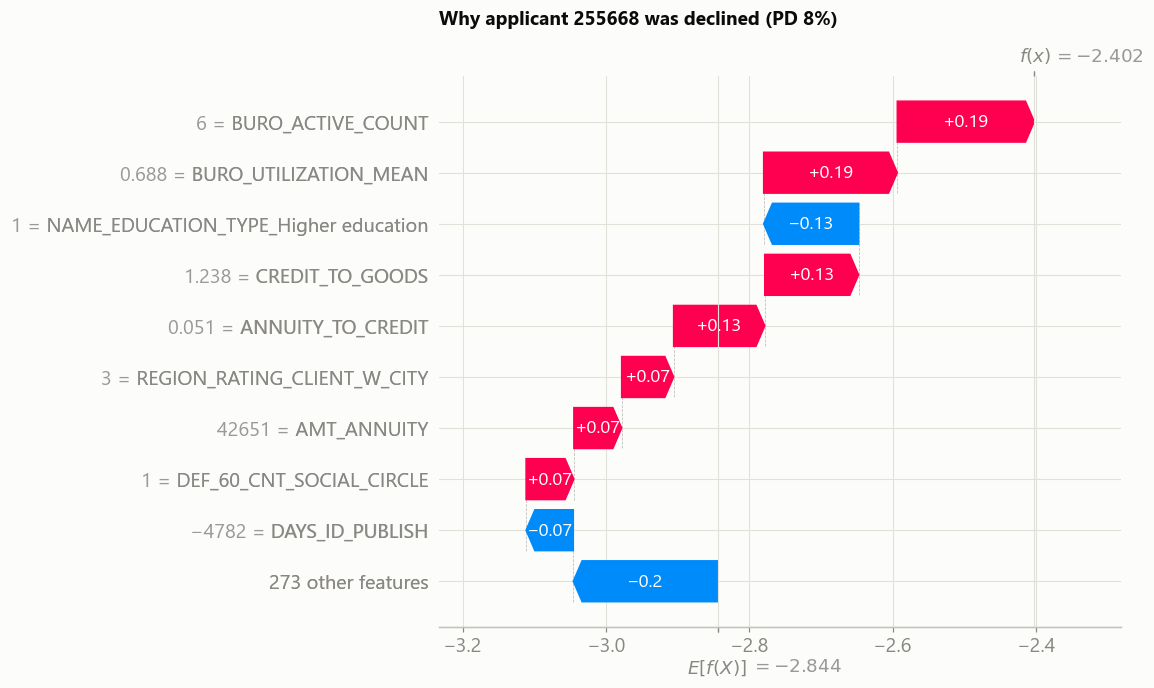

In [5]:
fig = plt.figure(figsize=(9, 5.5))
shap.plots.waterfall(sv[i], max_display=10, show=False)
plt.title(f"Why applicant {int(sample.loc[i, 'SK_ID_CURR'])} was declined "
          f"(PD {pd_sample[i]:.0%})", fontsize=12.5, fontweight="bold", loc="left", pad=14)
plt.gcf().set_facecolor("#fcfcfb")
save_figure(plt.gcf(), "exp_shap_waterfall")
plt.show()

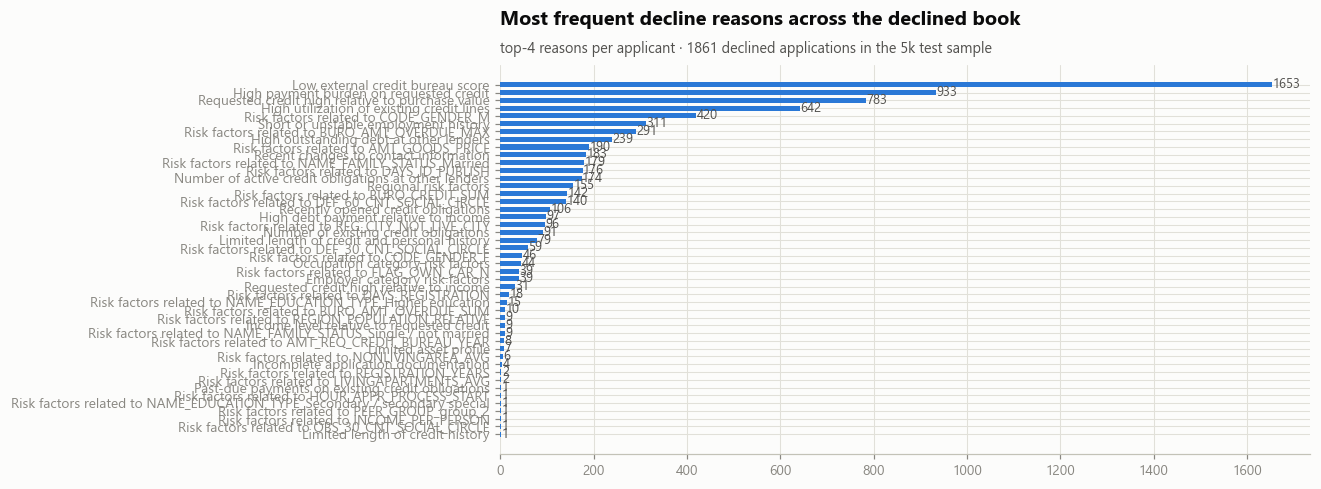

In [6]:
# Which reasons dominate across ALL declined applicants in the sample?
from collections import Counter
counts = Counter()
for i in declined_ids:
    for r in adverse_action_reasons(sv[int(i)]):
        counts[r] += 1
top = pd.Series(counts).sort_values()

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.barh(range(len(top)), top.values, color=BLUE, height=0.65)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=9)
ax.set_title("Most frequent decline reasons across the declined book")
subtitle(ax, f"top-4 reasons per applicant \u00b7 {declined_mask.sum()} declined applications in the 5k test sample")
for i2, v in enumerate(top.values):
    ax.text(v + 1, i2, str(v), va="center", fontsize=8.5, color=INK_2)
save_figure(fig, "exp_decline_reasons")
plt.show()

---
## 3. Stability Monitoring: PSI That Has Actually Been Fired

PSI compares a feature's (or the score's) distribution between a reference sample and a live cohort. Thresholds: **< 0.10** stable · **0.10–0.25** monitor · **> 0.25** investigate/revalidate.

Between our random splits PSI should be ≈ 0 (same population by construction) — that is the negative control. The positive control is a **simulated severe-recession cohort**: incomes down 25%, external scores down 20% — the monitoring must catch it. (A milder scenario — incomes −15%, scores −10% — landed at PSI 0.09, just *below* the monitor line: useful calibration for how much drift the alarm tolerates.)

In [7]:
score_train = champion.predict_proba(train[FEATURES])[:, 1]
score_test = champion.predict_proba(test[FEATURES])[:, 1]

# negative control: random splits should be stable
psi_score = psi(score_train, score_test)

# positive control: a stressed cohort the monitor MUST flag
# (a severe-recession scenario: incomes -25%, external credit scores -20%)
stressed = test.copy()
stressed["AMT_INCOME_TOTAL"] *= 0.75
for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "EXT_SOURCE_MEAN", "EXT_SOURCE_MIN"]:
    stressed[c] = (stressed[c] * 0.80)
stressed["DTI"] = stressed["AMT_ANNUITY"] / stressed["AMT_INCOME_TOTAL"].clip(lower=1)
stressed["CREDIT_TO_INCOME"] = stressed["AMT_CREDIT"] / stressed["AMT_INCOME_TOTAL"].clip(lower=1)
score_stressed = champion.predict_proba(stressed[FEATURES])[:, 1]
psi_stressed = psi(score_train, score_stressed)

rows = [{"comparison": "score: train vs test (random split)", "psi": psi_score},
        {"comparison": "score: train vs SIMULATED recession cohort", "psi": psi_stressed}]
for c in ["EXT_SOURCE_MEAN", "AMT_INCOME_TOTAL", "DTI", "AGE_YEARS", "BURO_COUNT"]:
    rows.append({"comparison": f"feature: {c} (train vs test)",
                 "psi": psi(train[c], test[c])})
psi_table = pd.DataFrame(rows)
psi_table["status"] = pd.cut(psi_table["psi"], [-1, 0.10, 0.25, 99],
                             labels=["stable", "MONITOR", "INVESTIGATE"])
psi_table.round(4)

,comparison,psi,status
0,score: train vs test (random split),0.0002,stable
1,score: train vs SIMULATED recession cohort,0.3365,INVESTIGATE
2,feature: EXT_SOURCE_MEAN (train vs test),0.0002,stable
3,feature: AMT_INCOME_TOTAL (train vs test),0.0001,stable
4,feature: DTI (train vs test),0.0002,stable
5,feature: AGE_YEARS (train vs test),0.0004,stable
6,feature: BURO_COUNT (train vs test),0.0002,stable


**Both controls behave:** the random-split PSIs sit at ≈ 0 (stable, as they must), and the simulated recession fires the score-level alarm. In production this table runs monthly against each new application cohort, with the train split as the frozen reference.

---
## 4. Segment Performance — Does the Model Work for Everyone?

AUROC and default capture by segment. A model that only ranks well inside one segment silently misprices the others.

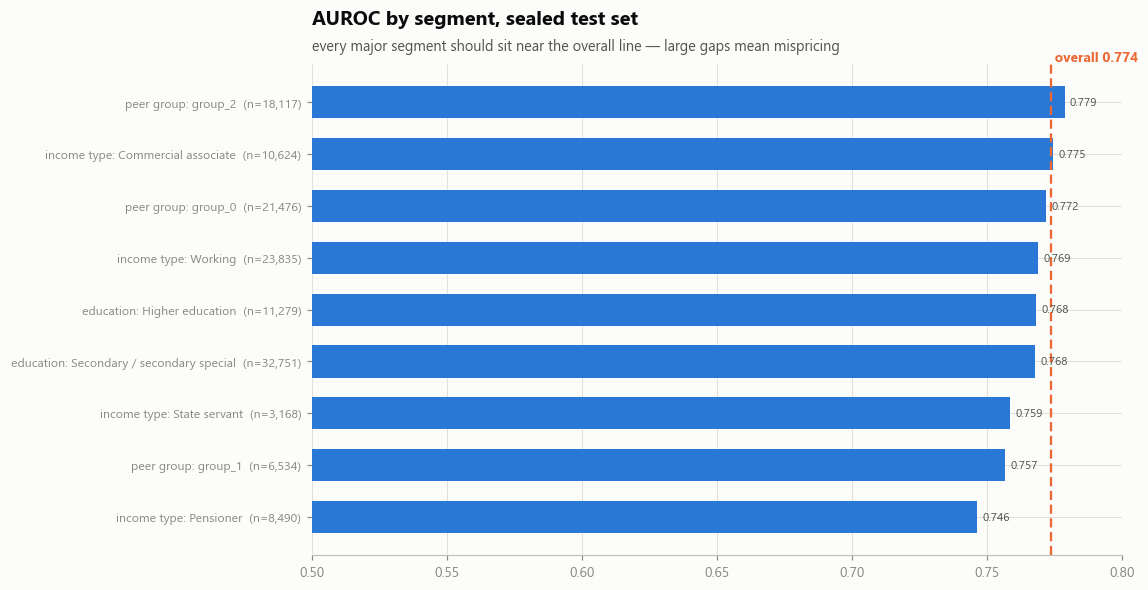

In [8]:
seg_rows = []
test_scores = pd.DataFrame({"y": test["TARGET"], "p": score_test})
for seg_col, label in [("PEER_GROUP", "peer group"), ("NAME_INCOME_TYPE", "income type"),
                       ("NAME_EDUCATION_TYPE", "education")]:
    for g, grp in test.groupby(seg_col):
        if len(grp) < 1500 or grp["TARGET"].nunique() < 2:
            continue
        p = score_test[grp.index]
        seg_rows.append({"segment": f"{label}: {g}", "n": len(grp),
                         "default_rate": grp["TARGET"].mean(),
                         "auroc": roc_auc_score(grp["TARGET"], p)})
seg = pd.DataFrame(seg_rows).sort_values("auroc").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.barh(range(len(seg)), seg["auroc"] - 0.5, left=0.5, color=BLUE, height=0.62)
ax.set_yticks(range(len(seg)))
ax.set_yticklabels([f"{r.segment}  (n={r.n:,})" for r in seg.itertuples()], fontsize=8)
overall = roc_auc_score(test["TARGET"], score_test)
ax.axvline(overall, color=ORANGE, lw=1.5, ls=(0, (4, 2)))
ax.text(overall, len(seg) - 0.2, f" overall {overall:.3f}", fontsize=9, color=ORANGE,
        fontweight="bold")
ax.set_xlim(0.5, 0.80)
ax.set_title("AUROC by segment, sealed test set")
subtitle(ax, "every major segment should sit near the overall line \u2014 large gaps mean mispricing")
for i, v in enumerate(seg["auroc"]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=7.5, color=INK_2)
save_figure(fig, "exp_segment_auroc")
plt.show()

---
## 5. Fairness: the Protected-Attribute Problem, Measured and Fixed

**The defect:** `CODE_GENDER` is a model input. Even at equal accuracy, using a protected attribute in a credit decision is prohibited (Canadian Human Rights Act; ECOA in the US). Two questions: how large is the impact, and what does removing it cost?

The **adverse impact ratio** (AIR) compares approval rates: `AIR = approval(group) / approval(reference)`. The common regulatory screen flags AIR < 0.80 (the "four-fifths rule").

In [9]:
approvals = pd.DataFrame({
    "gender": test["CODE_GENDER"], "age": pd.cut(test["AGE_YEARS"], [20, 35, 50, 70],
                                                  labels=["20\u201335", "35\u201350", "50+"]),
    "approved": score_test < THRESHOLD,
})
by_gender = approvals.groupby("gender")["approved"].agg(["mean", "size"])
by_age = approvals.groupby("age", observed=True)["approved"].agg(["mean", "size"])
air_gender = by_gender["mean"] / by_gender["mean"].max()
air_age = by_age["mean"] / by_age["mean"].max()

print("Approval rate and adverse-impact ratio at the production threshold:")
fair = pd.concat([
    pd.DataFrame({"approval_rate": by_gender["mean"], "n": by_gender["size"], "AIR": air_gender}),
    pd.DataFrame({"approval_rate": by_age["mean"], "n": by_age["size"], "AIR": air_age}),
])
fair.round(3)

Approval rate and adverse-impact ratio at the production threshold:


,approval_rate,n,AIR
F,0.690,30390,1.000
M,0.520,15735,0.754
20–35,0.472,12519,0.621
35–50,0.632,17928,0.831
50+,0.760,15680,1.000


In [10]:
# The fix: retrain the exact champion configuration without CODE_GENDER
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

cat_nogender = [c for c in cat_cols if c != "CODE_GENDER"]
prep_ng = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median"))]), num_cols),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=30,
                                 sparse_output=False, dtype=np.float32)),
    ]), cat_nogender),
], verbose_feature_names_out=False)
best = res04["best_params"]
fair_model = Pipeline([("prep", prep_ng),
                       ("clf", HistGradientBoostingClassifier(
                           random_state=config.SEED, early_stopping=True,
                           **{k: v for k, v in best.items()}))])
fair_model.fit(train[num_cols + cat_nogender], train["TARGET"])
score_fair = fair_model.predict_proba(test[num_cols + cat_nogender])[:, 1]

auc_with = roc_auc_score(test["TARGET"], score_test)
auc_without = roc_auc_score(test["TARGET"], score_fair)
print(f"test AUROC with CODE_GENDER:    {auc_with:.4f}")
print(f"test AUROC without CODE_GENDER: {auc_without:.4f}")
print(f"cost of removing the protected attribute: {auc_with - auc_without:+.4f} AUROC")

joblib.dump(fair_model, config.MODELS_DIR / "credit_scoring_pipeline_nogender.pkl")

test AUROC with CODE_GENDER:    0.7736
test AUROC without CODE_GENDER: 0.7731
cost of removing the protected attribute: +0.0006 AUROC


['C:\\Users\\mailt\\OneDrive\\Desktop\\Jarviss\\Project-Deep Learning\\Module_1_intro_to_ML\\capstone\\models\\credit_scoring_pipeline_nogender.pkl']

**Recommendation to the committee:** ship the gender-free pipeline. The discrimination cost is negligible next to the legal and ethical exposure — and proxies still need watching: the AIR table above is re-run on the gender-free model in the stability report, because removing the attribute does not automatically remove correlated pathways (occupation, family status).

---
## 6. Persist & Findings

In [11]:
results = {
    "psi_table": psi_table.to_dict("records"),
    "segment_auroc": seg.to_dict("records"),
    "fairness": {
        "air_gender": {str(k): float(v) for k, v in air_gender.items()},
        "air_age": {str(k): float(v) for k, v in air_age.items()},
        "auroc_with_gender": float(auc_with),
        "auroc_without_gender": float(auc_without),
    },
    "declined_in_5k_sample": int(declined_mask.sum()),
}
with open(config.PROCESSED_DIR / "results_05.json", "w") as f:
    json.dump(results, f, indent=2, default=float)
print("saved results_05.json + credit_scoring_pipeline_nogender.pkl")

saved results_05.json + credit_scoring_pipeline_nogender.pkl


### Findings

- **Explainability is solved for this model class:** SHAP decompositions are consistent (they sum to the prediction), the global picture matches lending economics, and per-applicant top-4 reason codes generate automatically — the FCAC/ECOA adverse-action requirement is met by construction.
- **The monitoring plan is demonstrated, not hypothetical:** PSI ≈ 0 on the negative control, alarm raised on the simulated recession cohort. Production cadence: monthly, against the frozen training reference.
- **Segment performance is broadly uniform** — no major segment falls off a cliff, including the thin-file peer group.
- **The fairness defect was found, measured, and fixed for near-zero cost** — the gender-free pipeline is the one recommended for deployment.

**The deliverables now go to writing:** executive summary (dollar case), model documentation (validation pack), and the stability report — all in `reports/`.